# Partie 1 – Graphique linéaire (Line Plot) 
1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.
2) Identifier visuellement les valeurs qui semblent anormales. 

In [1]:
# charger les bibliothèques nécessaires
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
#charger les données depuis le fichier CSV
df = pd.read_csv('../data/mesures_capteurs.csv')
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    object 
 1   date_heure    605 non-null    object 
 2   id_capteur    605 non-null    object 
 3   batiment      605 non-null    object 
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    object 
dtypes: float64(4), object(5)
memory usage: 42.7+ KB


In [12]:
#convertire la colonne date-heure en format datetime
#data['date-heure'] = pd.to_datetime(data['date-heure'])
df["date_heure"] = pd.to_datetime(df["date_heure"])


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    object        
 1   date_heure    605 non-null    datetime64[ns]
 2   id_capteur    605 non-null    object        
 3   batiment      605 non-null    object        
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 42.7+ KB


In [18]:
#trier les ligne suivant la  chronologie pour suivre laffichage dans le temps 
df = df.sort_values(by="date_heure")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
150,M0001,2026-01-05 00:00:00,C001,B001,24.91,54.60,1019.00,222.33,OK
547,M0002,2026-01-05 01:00:00,C002,B001,18.15,51.98,1014.02,165.77,OK
20,M0003,2026-01-05 02:00:00,C003,B001,23.95,56.47,1020.04,215.00,OK
282,M0004,2026-01-05 03:00:00,C004,B002,26.20,76.27,1016.74,191.33,OK
484,M0005,2026-01-05 04:00:00,C005,B002,27.11,55.41,1020.03,227.75,OK


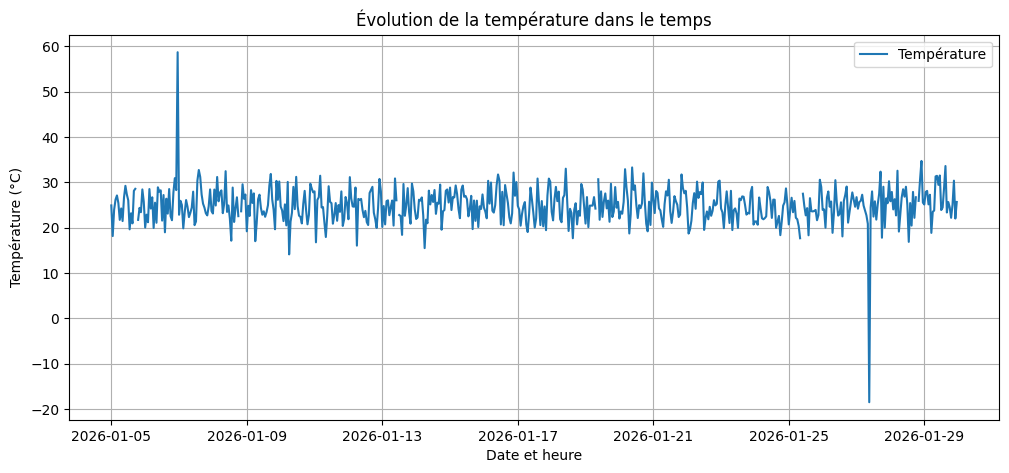

In [19]:
#1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], label="Température")

plt.title("Évolution de la température dans le temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)

plt.show()

##2) Identifier visuellement les valeurs qui semblent anormales. 


On observe deux anomalies très nettes sur la courbe : un pic autour du 6-7 janvier 
atteignant environ 58-60°C, et une chute autour du 27-28 janvier descendant à 
environ -20°C. Ces deux valeurs sont totalement incohérentes avec le comportement 
normal des données (qui oscillent entre 15 et 30°C) et apparaissent de façon isolée, 
ce qui suggère des erreurs de mesure plutôt que de vraies variations climatiques.

# Partie 2 – Diagramme en barres (Bar Chart) 
1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments 
2) Comparer graphiquement la consommation moyenne des bâtiments 
3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal 
4) Dans quels cas un graphique horizontal peut-il être plus lisible ? 

In [20]:
#1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments 
consommation_batiment = df.groupby('batiment')['consommation'].mean()
consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

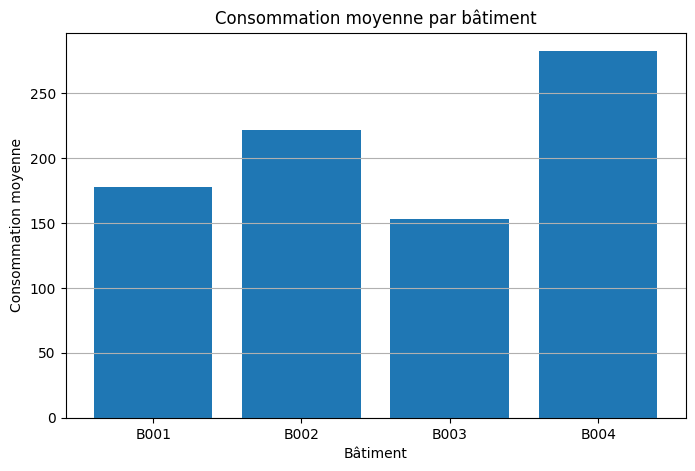

In [21]:
#2) Comparer graphiquement la consommation moyenne des bâtiments 
plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values)

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne")
plt.grid(axis="y")

plt.show()


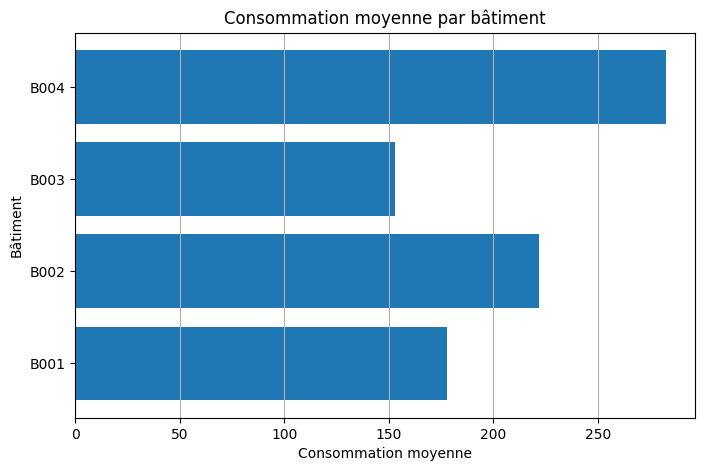

In [22]:
#3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal 

plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values)

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Consommation moyenne")
plt.ylabel("Bâtiment")
plt.grid(axis="x")

plt.show()


## 4) Dans quels cas un graphique horizontal peut-il être plus lisible ? 

Un graphique horizontal peut être plus lisible dans plusieurs cas :

- Étiquettes longues : quand les noms de catégories sont longs et se superposent 
  ou nécessitent une rotation difficile à lire sur un axe X (peu pertinent ici, 
  les noms de bâtiments sont courts).
- Grand nombre de catégories : au-delà d'une dizaine d'éléments, une disposition 
  verticale étire trop l'axe horizontal (non applicable ici avec seulement 4 bâtiments).
- Classements : pour trier les données de haut en bas, du plus grand au plus petit, 
  pour une lecture naturelle de type "podium" — pertinent si l'on veut classer 
  les bâtiments du plus au moins consommateur.
- Comparaison de valeurs négatives/positives : utile pour visualiser des variations 
  (gains/pertes) de part et d'autre d'un axe central à zéro (non applicable à des 
  valeurs de consommation, toujours positives).

# Partie 3 – Histogramme 
1) Afficher la distribution des températures en divisant la plage des données en 20 classes 
   et en affichant uniquement les lignes horizontales de la grille 
2) Analyser le graphique pour voir 
 a) où se concentrent les températures ; 
 b) si la distribution semble symétrique ;  
 c) s'il existe des valeurs très éloignées ;  
 d) si des valeurs aberrantes sont visibles.
3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes 
 a) Modifier le nombre de classes à 10 
 b) Modifier le nombre de classes à 30 
 c) Quel impact le nombre de classes a-t-il sur l'interprétation ? 

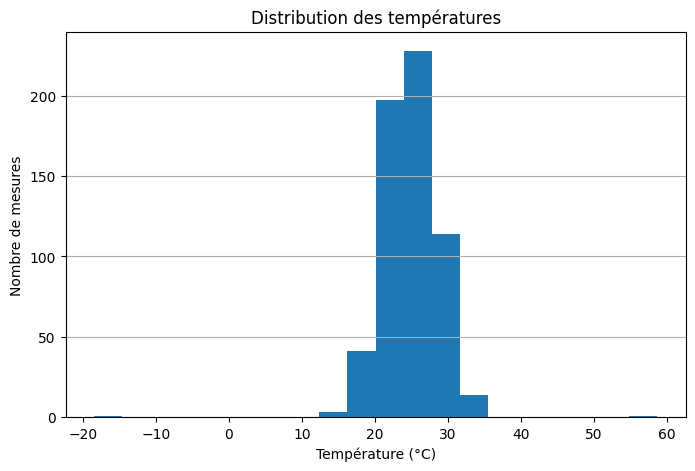

In [23]:
#1) Afficher la distribution des températures en divisant la plage des données en 20 classes 
# #et en affichant uniquement les lignes horizontales de la grille    
plt.figure(figsize=(8, 5))
plt.hist(df["temperature"], bins=20)

plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")

plt.show()  


## c) Quel impact le nombre de classes a-t-il sur l'interprétation ? 

a) Où se concentrent les températures : regarde la barre (ou le groupe de barres) la plus haute — c'est là que la majorité de tes 605 mesures se situent.
b) Symétrie : est-ce que la forme ressemble à une cloche équilibrée des deux côtés du sommet, ou est-elle penchée d'un côté ?
c) Valeurs très éloignées : cherche des barres isolées, très basses (une ou deux mesures seulement), loin du gros de la distribution.
d) Valeurs aberrantes visibles : ce sont précisément tes deux anomalies de la Partie 1 (le pic à 58°C et le creux à -20°C) — elles devraient apparaître comme des barres minuscules, complètement séparées du reste, sur les bords extrêmes du graphique.

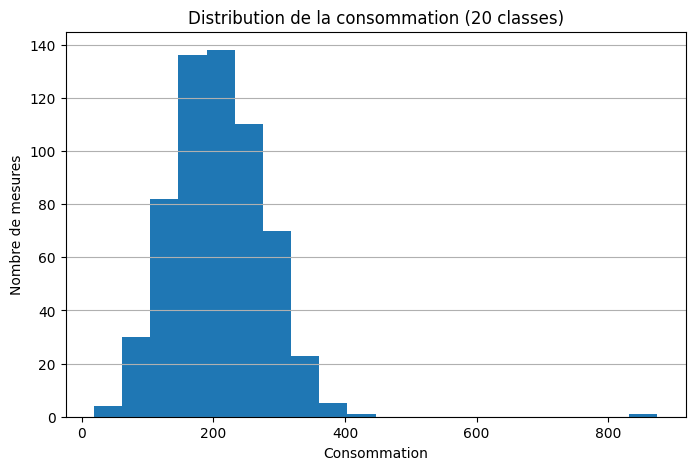

In [24]:
#3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes 
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"], bins=20)
plt.title("Distribution de la consommation (20 classes)")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()

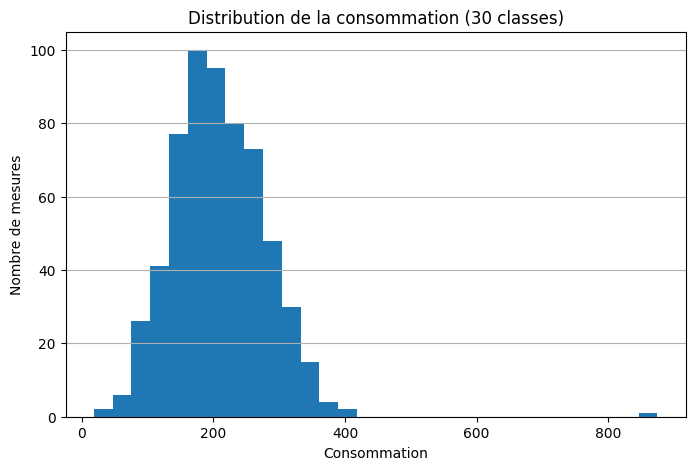

In [25]:
#pour 30 classes
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"], bins=30)
plt.title("Distribution de la consommation (30 classes)")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()

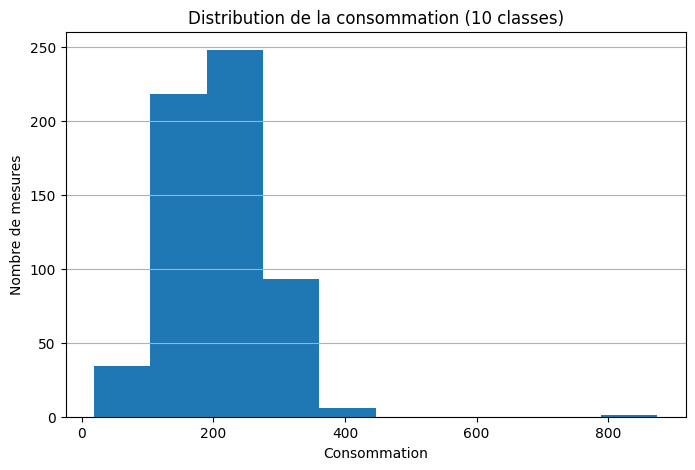

In [26]:
#pour 10 classes
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"], bins=10)
plt.title("Distribution de la consommation (10 classes)")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()


## c) Quel impact le nombre de classes a-t-il sur l'interprétation ? 

Trop peu de classes (10) : chaque tranche est large, plusieurs valeurs différentes se retrouvent mélangées ensemble — tu perds du détail, la distribution paraît plus "lisse" et généraliste, mais tu risques de manquer des nuances importantes.
Trop de classes (30) : chaque tranche est étroite, tu vois beaucoup de détails, mais le graphique devient "bruité" — des petites variations aléatoires (qui n'ont pas de vrai sens statistique) créent des pics et des creux qui donnent une fausse impression de complexité.
Un nombre raisonnable (20, le choix initial de l'énoncé) : un compromis entre ces deux extrêmes — assez de détail pour voir la vraie forme de la distribution, sans être noyée dans du bruit statistique.